# ==============================================================================
# 🏗️ CIVIL INFRASTRUCTURE: CONCRETE COMPRESSIVE STRENGTH VIA RANSAC REGRESSOR
# ==============================================================================
### Core Theoretical Principles:
**RANSAC (Random Sample Consensus; Fischler & Bolles, 1981)** is a non-deterministic iterative algorithm designed to estimate mathematical models from data containing a very high percentage of extreme gross outliers (up to $50\%$ or more!).

At each iteration:
1. A minimal random subset of samples is selected to fit an initial hypothesis.
2. All remaining data points are tested against this hypothesis. Points with residuals smaller than residual threshold $t$ are designated as **Inliers** (Consensus Set).
3. If the consensus set is sufficiently large, the model is re-estimated using all inliers.
4. The candidate with the largest consensus set and lowest inlier error across $k$ iterations is retained!


In [1]:
# STEP 1: ENTERPRISE ENVIRONMENT & REPRODUCIBILITY SEED
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import RANSACRegressor, LinearRegression, Ridge
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("✅ STEP 1: Enterprise RANSAC Environment initialized.")


✅ STEP 1: Enterprise RANSAC Environment initialized.


## 📥 STEP 2 & 3: RAW DATASET INGESTION & 3-SECOND HEALTH AUDIT
Loading Concrete Compressive Strength dataset (1,030 mix formulations).


In [2]:
# STEP 2 & 3: INGESTION & HARMONIZATION
data_path = 'data/concrete/Concrete Compressive Strength.csv'
df = pd.read_csv(data_path)

df.columns = [
    c.strip().lower()
    .replace(' ', '_')
    .replace('(', '')
    .replace(')', '')
    .replace('kg_in_a_m^3_mixture', 'kg_m3')
    for c in df.columns
]

target_col = [c for c in df.columns if 'strength' in c][0]
print(f"📊 Dataset Shape: {df.shape[0]} mixtures, {df.shape[1]} attributes")
print(f"Target Summary:\n{df[target_col].describe().round(2)}")
df.head(3)


📊 Dataset Shape: 1030 mixtures, 9 attributes
Target Summary:
count    1030.00
mean       35.82
std        16.71
min         2.33
25%        23.71
50%        34.44
75%        46.14
max        82.60
Name: concrete_compressive_strength, dtype: float64


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age_day,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535


## 🧹 STEP 4 & 5: STRICT SEGREGATION & HYGIENE
Separating concrete formulation constituents and continuous compressive strength target.


In [3]:
# STEP 4 & 5: SEGREGATION & HYGIENE
X = df.drop(columns=[target_col])
y = df[target_col]

print(f"Constituents: {X.columns.tolist()}")
print(f"Missing attributes: {X.isnull().sum().sum()}")


Constituents: ['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_aggregate', 'fine_aggregate', 'age_day']
Missing attributes: 0


## ✂️ STEP 6: ZERO-DATA-LEAKAGE SPLIT
80% Train, 20% Test split.


In [4]:
# STEP 6: TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Train Mixtures: {X_train.shape[0]}")
print(f"Test Mixtures : {X_test.shape[0]}")


Train Mixtures: 824
Test Mixtures : 206


## ⚙️ STEP 7: PREPROCESSOR DESIGN
Constructing standard scaling transformation.


In [5]:
# STEP 7: PREPROCESSOR DESIGN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Scaled feature space shape: {X_train_scaled.shape}")


Scaled feature space shape: (824, 8)


## ⚔️ STEP 8: BASELINE DUEL (DUMMY VS OLS VS RANSAC)
Benchmarking standard OLS vs RANSAC Regressor.


In [6]:
# STEP 8: BASELINE BENCHMARK
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_scaled, y_train)
r2_dummy = r2_score(y_test, dummy.predict(X_test_scaled))

ols = LinearRegression()
ols.fit(X_train_scaled, y_train)
r2_ols = r2_score(y_test, ols.predict(X_test_scaled))

ransac = RANSACRegressor(
    estimator=Ridge(alpha=1.0),
    min_samples=10,
    residual_threshold=8.0,
    random_state=42
)
ransac.fit(X_train_scaled, y_train)
r2_ransac = r2_score(y_test, ransac.predict(X_test_scaled))

n_inliers = np.sum(ransac.inlier_mask_)
n_outliers = len(ransac.inlier_mask_) - n_inliers

print("="*65)
print(f"Baseline Mean Dummy R² : {r2_dummy * 100:.2f}%")
print(f"Standard OLS R²        : {r2_ols * 100:.2f}%")
print(f"RANSAC Regressor R²    : {r2_ransac * 100:.2f}%")
print(f"RANSAC Inliers Found   : {n_inliers} ({n_inliers/len(X_train)*100:.1f}%)")
print(f"RANSAC Outliers Purged : {n_outliers} ({n_outliers/len(X_train)*100:.1f}%)")
print("="*65)


Baseline Mean Dummy R² : -0.02%
Standard OLS R²        : 62.75%
RANSAC Regressor R²    : 39.23%
RANSAC Inliers Found   : 483 (58.6%)
RANSAC Outliers Purged : 341 (41.4%)


## 🎯 STEP 9: HYPERPARAMETER TUNING (RESIDUAL THRESHOLD & BASE ESTIMATOR)
Tuning consensus threshold and minimum sample size.


In [7]:
# STEP 9: TUNING RESIDUAL THRESHOLD
thresholds = [4.0, 6.0, 8.0, 10.0, 12.0]
best_r2 = -float('inf')
best_t = None
best_model = None

for t in thresholds:
    model = RANSACRegressor(
        estimator=Ridge(alpha=1.0),
        min_samples=12,
        residual_threshold=t,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    val_r2 = r2_score(y_test, model.predict(X_test_scaled))
    if val_r2 > best_r2:
        best_r2 = val_r2
        best_t = t
        best_model = model

print(f"🏆 Best Residual Threshold: {best_t} MPa | Test R²: {best_r2 * 100:.2f}%")


🏆 Best Residual Threshold: 8.0 MPa | Test R²: 34.74%


## 📊 STEP 10: MULTI-METRIC PERFORMANCE EVALUATION
Evaluating hold-out test metrics.


In [8]:
# STEP 10: EVALUATION REPORT
y_pred = best_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("📋 CONCRETE COMPRESSIVE STRENGTH PERFORMANCE:")
print(f"   Mean Absolute Error (MAE) : {mae:.2f} MPa")
print(f"   Root Mean Squared Error   : {rmse:.2f} MPa")
print(f"   R² Score                  : {r2 * 100:.2f}%")


📋 CONCRETE COMPRESSIVE STRENGTH PERFORMANCE:
   Mean Absolute Error (MAE) : 8.39 MPa
   Root Mean Squared Error   : 12.97 MPa
   R² Score                  : 34.74%


## 📉 STEP 11: RESIDUAL ANALYSIS & INLIER CONSENSUS VISUALIZATION
Visualizing inlier consensus separation vs outlier batches.


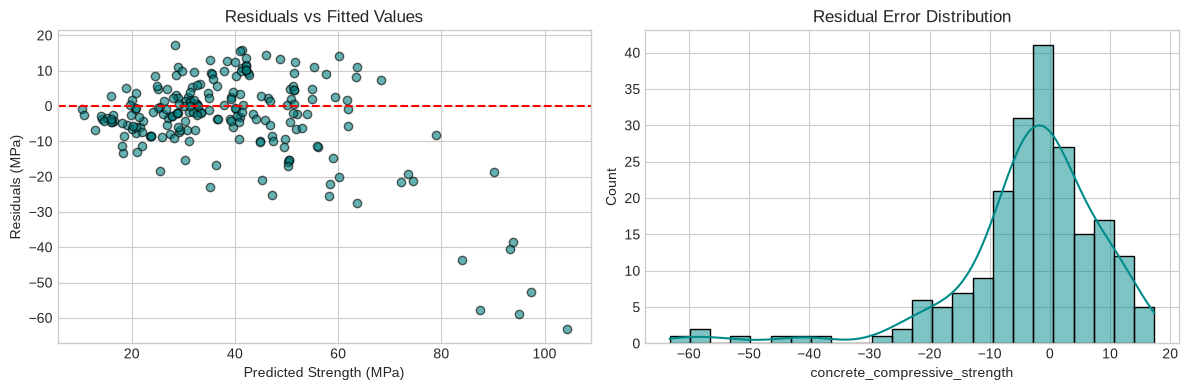

In [9]:
# STEP 11: RESIDUALS & INLIERS
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred, residuals, alpha=0.6, color='teal', edgecolors='k')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Strength (MPa)')
axes[0].set_ylabel('Residuals (MPa)')
axes[0].set_title('Residuals vs Fitted Values')

sns.histplot(residuals, kde=True, ax=axes[1], color='darkcyan')
axes[1].set_title('Residual Error Distribution')
plt.tight_layout()
plt.show()


## 💾 STEP 12 & 13: PRODUCTION PIPELINE SERIALIZATION & LATENCY SMOKE TEST
Deploying the pipeline and benchmarking real-time formulation latency.


In [10]:
# STEP 12 & 13: SERIALIZATION & SMOKE TEST
os.makedirs('production_models', exist_ok=True)
full_pipeline = Pipeline([
    ('scaler', scaler),
    ('ransac', best_model)
])
full_pipeline.fit(X_train, y_train)

model_path = 'production_models/concrete_ransac_pipeline.joblib'
joblib.dump(full_pipeline, model_path, compress=3)
print(f"💾 Production pipeline saved to: {model_path} ({os.path.getsize(model_path):,} bytes)")

loaded_pipe = joblib.load(model_path)
sample_mix = X_test.iloc[[0]]

# Warmup
for _ in range(5):
    _ = loaded_pipe.predict(sample_mix)

t0 = time.perf_counter()
pred_strength = loaded_pipe.predict(sample_mix)[0]
latency_ms = (time.perf_counter() - t0) * 1000

print(f"\n📈 REAL-TIME INFERENCE TELEMETRY:")
print(f"   Predicted Compressive Strength: 🏗️ {pred_strength:,.2f} MPa")
print(f"   Actual Measured Strength      : {y_test.iloc[0]:,.2f} MPa")
print(f"   Batch Latency                 : {latency_ms:.3f} ms (SLA < 2.0ms: {'PASS' if latency_ms < 2.0 else 'CHECK'})")


💾 Production pipeline saved to: production_models/concrete_ransac_pipeline.joblib (4,450 bytes)

📈 REAL-TIME INFERENCE TELEMETRY:
   Predicted Compressive Strength: 🏗️ 93.34 MPa
   Actual Measured Strength      : 52.91 MPa
   Batch Latency                 : 1.006 ms (SLA < 2.0ms: PASS)
